In [3]:
import pandas as pd

In [6]:
data=pd.read_csv("C:\\Users\\admin\\Downloads\\done_dataset_significant_features.csv")

In [8]:
data.head()

,Age,Composition,Margin,Calcification,Echo Strength,Shape,Multifocality,FT3,Size,Blood Flow,Multilateral,Result
0,46,1,0,0,4,0,0,4,5,0,1,1
1,61,2,1,1,4,0,0,5,4,1,1,1
2,44,2,1,0,4,0,0,4,1,0,1,0
3,29,2,1,1,4,1,1,4,1,0,1,1
4,37,2,1,1,4,0,0,4,1,0,1,1


In [67]:
categorial=['Composition','Margin','Calcification','Shape','Multifocality','Blood Flow','Multilateral','Result']

In [69]:
numerical=['Size','FT3','Echo Strength','Age']

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

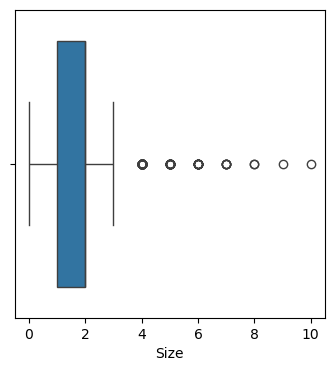

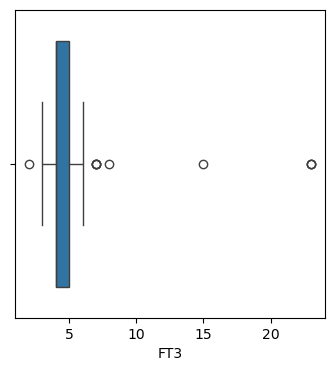

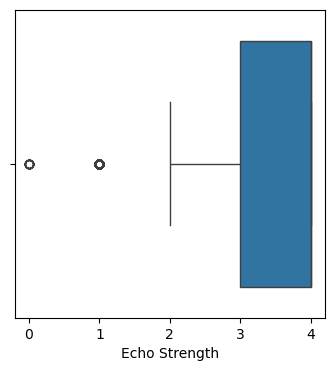

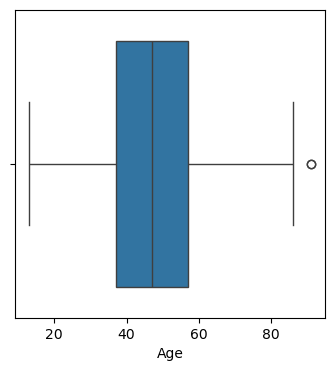

In [73]:
for col in numerical:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x=data[col])  # or y=data[col] for vertical boxplot
    plt.xlabel(col)
    plt.show()

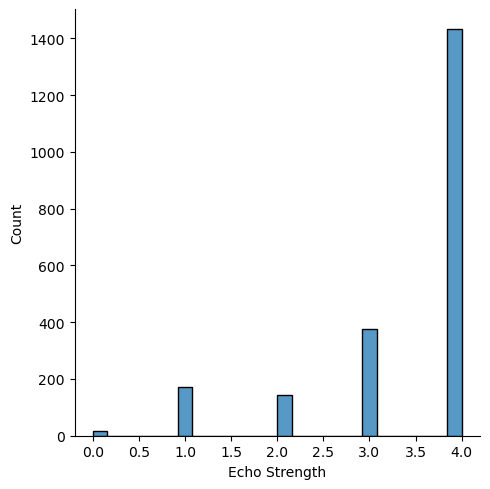

In [75]:
sns.displot(x=data['Echo Strength'])

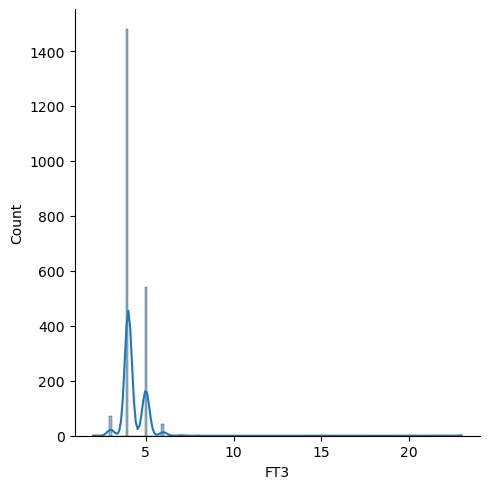

In [55]:
sns.displot(x=data['FT3'],kde=True)

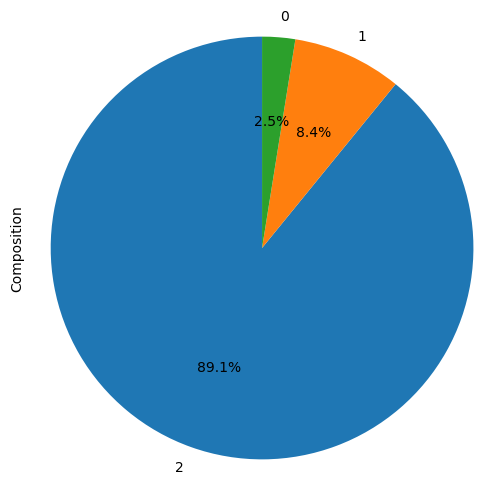

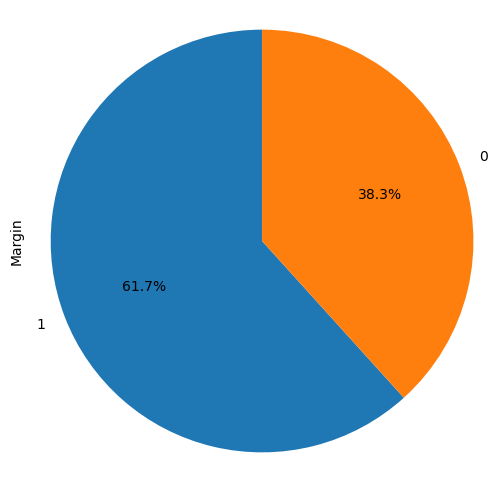

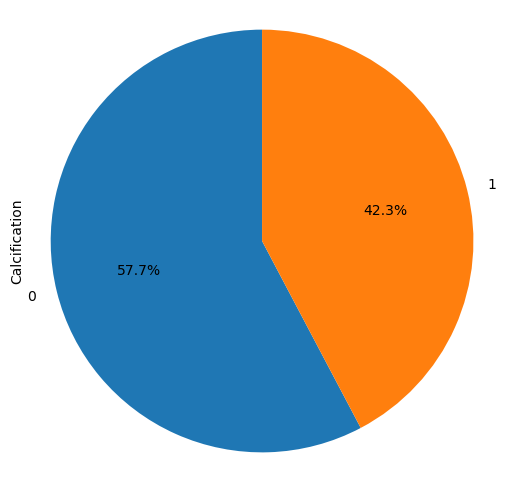

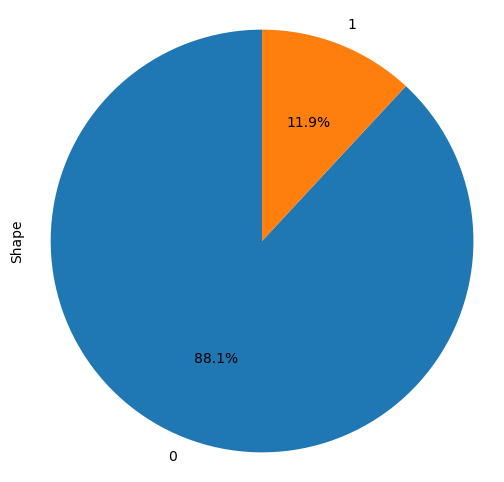

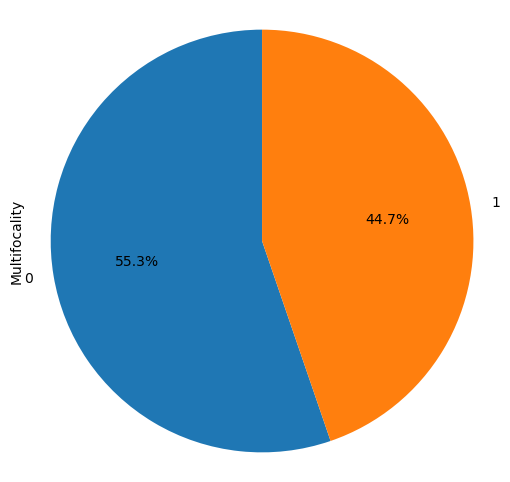

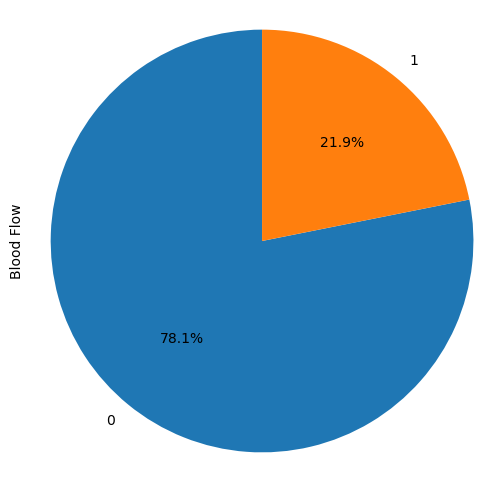

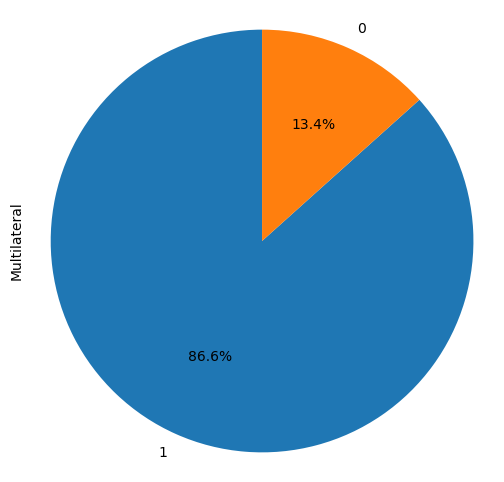

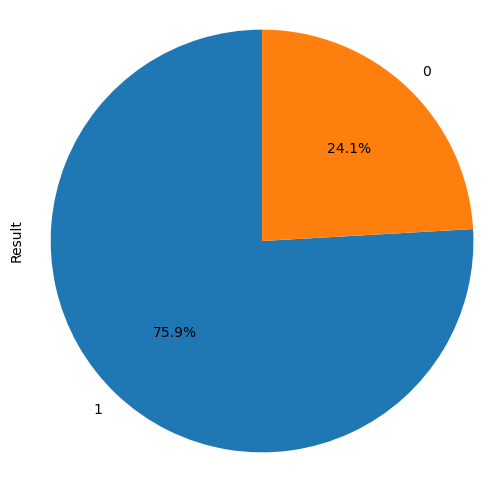

In [79]:
import matplotlib.pyplot as plt

for col in categorial:
    counts = data[col].value_counts()  # call value_counts() on the Series
    plt.figure(figsize=(6,6))
    counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.ylabel(col)  # Hide the y-label (default is 'count')
    plt.axis('equal')  # Make it a circle
    plt.show()


In [89]:
features=data.corr()['Result'].drop('Result')

<Axes: >

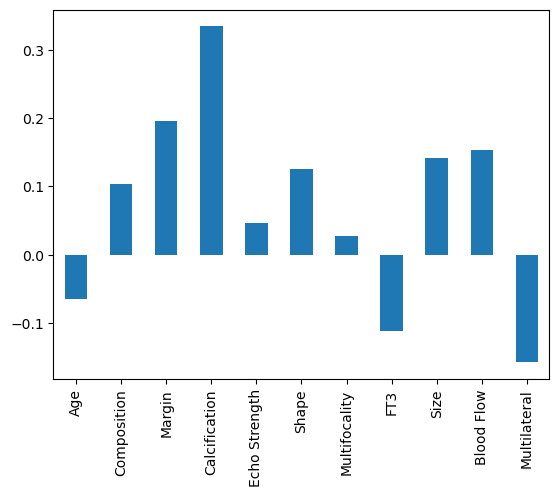

In [91]:
features.plot(kind='bar')

In [7]:
data.isna().sum()

Age              0
Composition      0
Margin           0
Calcification    0
Echo Strength    0
Shape            0
Multifocality    0
FT3              0
Size             0
Blood Flow       0
Multilateral     0
Result           0
dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [10]:
y=data['Result']
x=data.drop(columns=['Result'])

In [11]:
x.head()

,Age,Composition,Margin,Calcification,Echo Strength,Shape,Multifocality,FT3,Size,Blood Flow,Multilateral
0,46,1,0,0,4,0,0,4,5,0,1
1,61,2,1,1,4,0,0,5,4,1,1
2,44,2,1,0,4,0,0,4,1,0,1
3,29,2,1,1,4,1,1,4,1,0,1
4,37,2,1,1,4,0,0,4,1,0,1


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

scaler=StandardScaler()

x_trained=scaler.fit_transform(x_train)

x_tested=scaler.transform(x_test)

In [13]:
param={
    'n_estimators':[100,200,300,400,500],
    'max_depth':[None,10,20,30,40],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features': [ 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [ ]:
forest=RandomForestClassifier()
random_search = RandomizedSearchCV(
    estimator=forest,
    param_distributions=param,
    n_iter=50,  
    cv=5,    
    verbose=1,
   n_jobs=-1   
)
random_search.fit(x_trained,y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_tested)
accuracy_score(y_test,y_pred)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [23]:
forest2=RandomForestClassifier(n_estimators=300)
forest2.fit(x_trained,y_train)
y_diff=forest2.predict(x_tested)
accuracy_score(y_test,y_diff)

0.8298368298368298

In [25]:
logistic=LogisticRegression(max_iter=100000)
logistic.fit(x_trained,y_train)
y_pred2=logistic.predict(x_tested)
accuracy_score(y_test,y_pred2)

0.8135198135198135

In [27]:
knn=KNeighborsClassifier(n_neighbors=20)
knn.fit(x_trained,y_train)
y_pred3=knn.predict(x_tested)
accuracy_score(y_test,y_pred3)

0.8251748251748252

In [29]:
import tensorflow

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2  

In [31]:
early_stopping=EarlyStopping(patience=5,monitor='val_accuracy',restore_best_weights=True)

In [32]:
model=Sequential()
model.add(Dense(512,input_dim=x.shape[1],activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [34]:
model.fit(x_trained,y_train,batch_size=16,epochs=30,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7361 - loss: 0.5585 - val_accuracy: 0.8105 - val_loss: 0.4245
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8018 - loss: 0.4418 - val_accuracy: 0.7959 - val_loss: 0.3992
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7983 - loss: 0.4603 - val_accuracy: 0.8017 - val_loss: 0.4001
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8320 - loss: 0.4125 - val_accuracy: 0.8017 - val_loss: 0.3890
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8250 - loss: 0.3855 - val_accuracy: 0.8134 - val_loss: 0.3869
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8338 - loss: 0.3822 - val_accuracy: 0.8309 - val_loss: 0.3715
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8329 - loss: 0.4020 - val_accuracy: 0.8017 - val_loss: 0.3896
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8274 - loss: 0.4308 - val_accuracy: 0.8222 - v

In [35]:
y_pred4=(model.predict(x_tested)>0.5).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [36]:
test_loss, test_acc = model.evaluate(x_tested, y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8440 - loss: 0.3839


In [37]:
accuracy_score(y_test,y_pred4)

0.8461538461538461

In [38]:
from sklearn.svm import SVC

In [39]:
svm=SVC(kernel='rbf',C=3.0,gamma='scale')

In [40]:
svm.fit(x_trained,y_train)
y_pred6=svm.predict(x_tested)
accuracy_score(y_test,y_pred6)

0.8461538461538461

In [41]:
len(data)

2141